In [1]:
import cv2
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
# import skimage as ski
from skimage import color as ski_color
from skimage import io as ski_io
from skimage import transform as ski_transform
from skimage import feature as ski_feature

C:\MySoftware\Anaconda3\lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\MySoftware\Anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\MySoftware\Anaconda3\lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


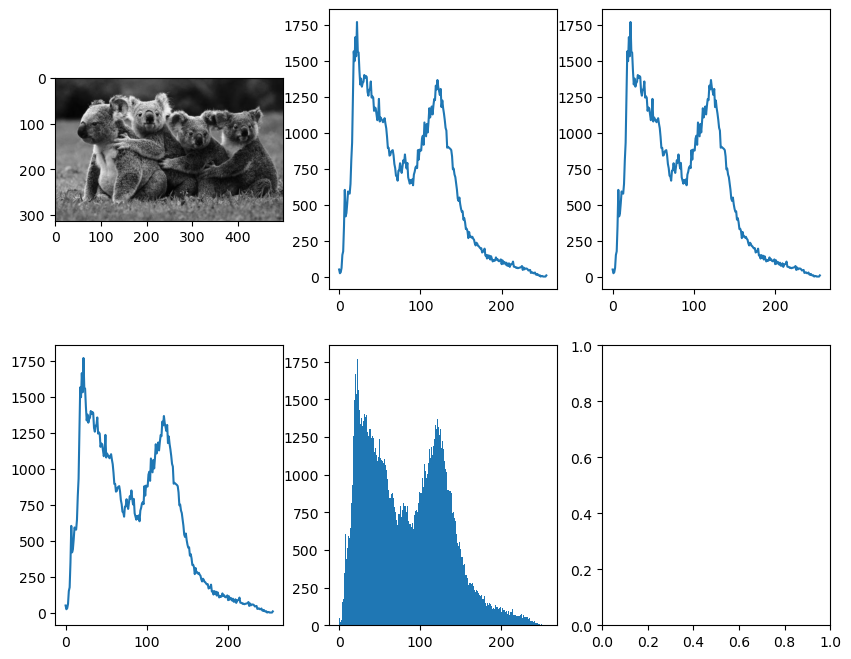

In [2]:
img = cv.imread('../images/koala.png', 0)

hist1 = cv.calcHist([img], [0], None, [256], [0, 256])

hist2, bins = np.histogram(img.ravel(), 256, [0, 256])

hist3 = np.bincount(img.ravel(), minlength=256)

fig, axex = plt.subplots(2, 3, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img, cmap='gray')
axex[0, 1].plot(hist1)
axex[0, 2].plot(hist2)
axex[1, 0].plot(hist3)
axex[1, 1].hist(img.ravel(), 256, [0, 256])
plt.show()

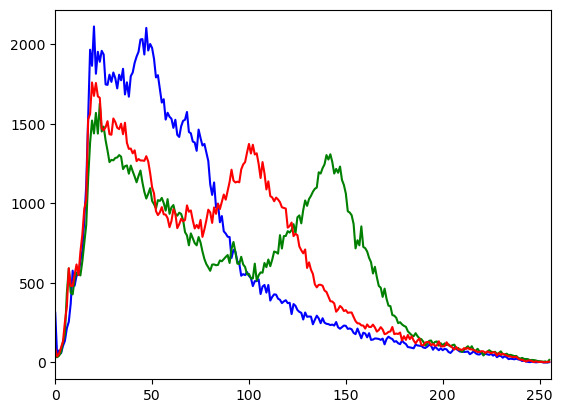

In [3]:
img = cv.imread('../images/koala.png')
color = ['b', 'g', 'r']

for i, color in enumerate(color):
    histr = cv.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(histr, color=color)
    plt.xlim([0, 256])
plt.show()

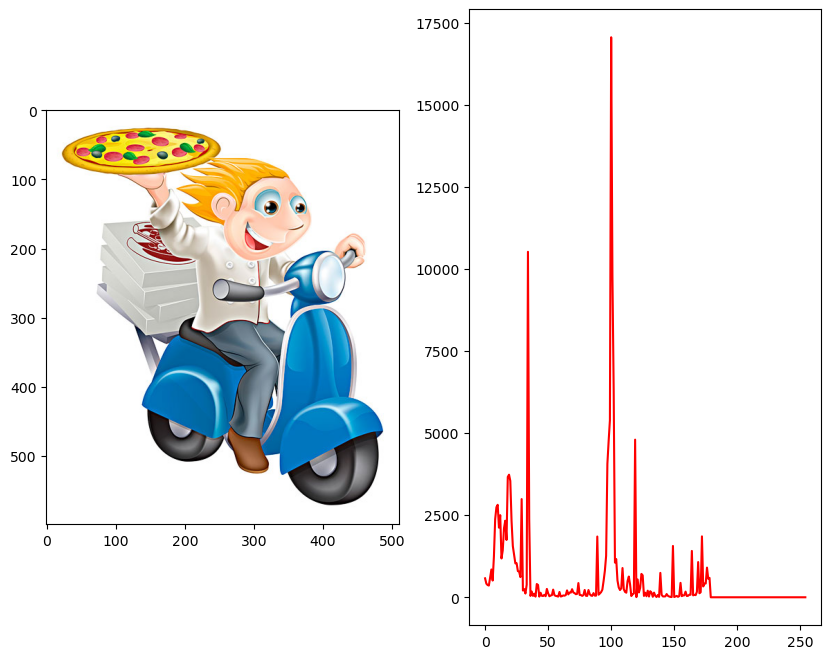

In [4]:
img = cv.imread('../images/xiaoren.png')

hsv_img = cv.cvtColor(img, cv.COLOR_BGR2HSV)

histr = cv.calcHist([hsv_img], [0], None, [256], [0, 256])[1:, :]

fig, axex = plt.subplots(1, 2, figsize=(10, 8), dpi=100)
axex[0].imshow(img[:, :, ::-1])
axex[1].plot(histr, color='r')
plt.show()

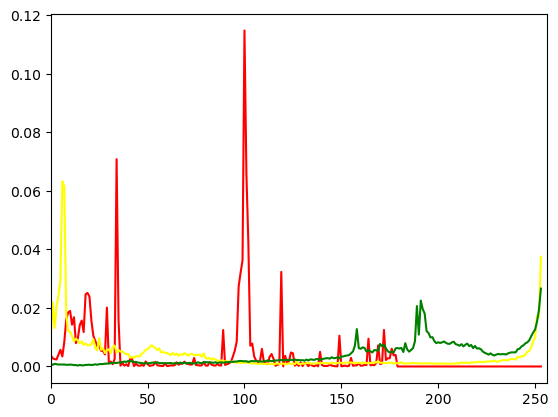

In [5]:
img = cv.imread('../images/xiaoren.png')
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)
color = ('red', 'yellow', 'green')
for i, color in enumerate(color):
    histr = cv.calcHist([img], [i], None, [256], [0, 256])[1:255, :]
    histr = histr / np.sum(histr)
    plt.plot(histr, color=color)
    plt.xlim([0, 256])
plt.show()

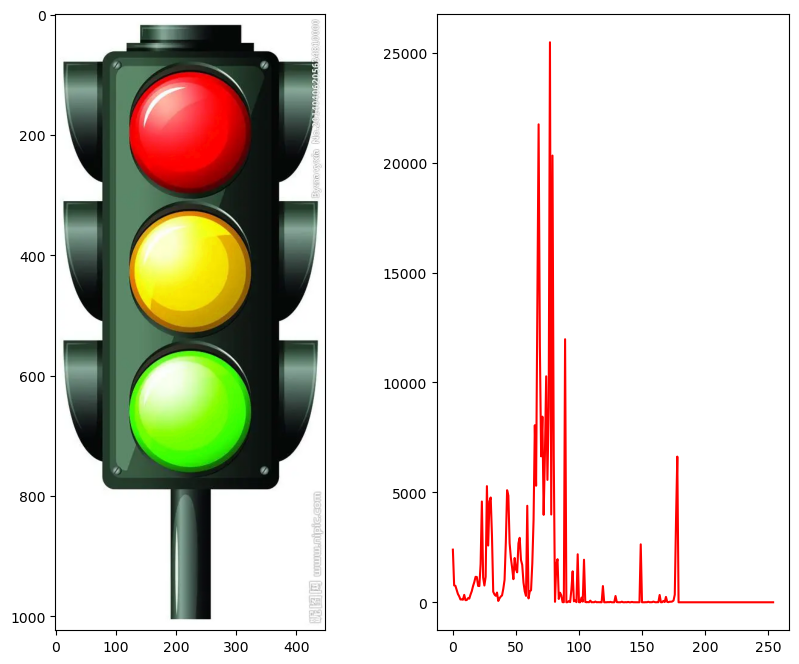

In [6]:
img = cv.imread("../images/t.png")
# 转为 HSV 格式
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)

chistr = cv.calcHist([img], [0], None, [256], [0, 256])[1:, :]

fig, axex = plt.subplots(1, 2, figsize=(10, 8), dpi=100)
axex[0].imshow(cv.cvtColor(img, cv.COLOR_HSV2RGB))
axex[1].plot(chistr, color='r')
plt.show()

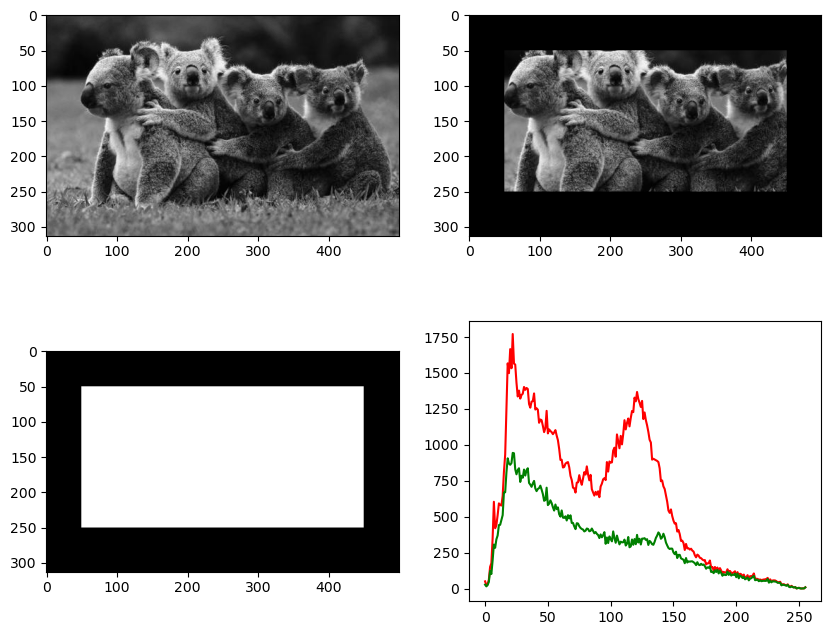

In [7]:
img = cv.imread('../images/koala.png', 0)
mask = np.zeros(img.shape[:2], np.uint8)
mask[50:250, 50:450] = 255

masked_img = cv.bitwise_and(img, img, mask=mask)

hist1 = cv.calcHist([img], [0], None, [256], [0, 256])
hist2 = cv.calcHist([masked_img], [0], mask, [256], [0, 256])

fig, axex = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img, cmap='gray')
axex[0, 1].imshow(masked_img, cmap='gray')
axex[1, 0].imshow(mask, cmap='gray')
axex[1, 1].plot(hist1, color='r')
axex[1, 1].plot(hist2, color='g')
plt.show()

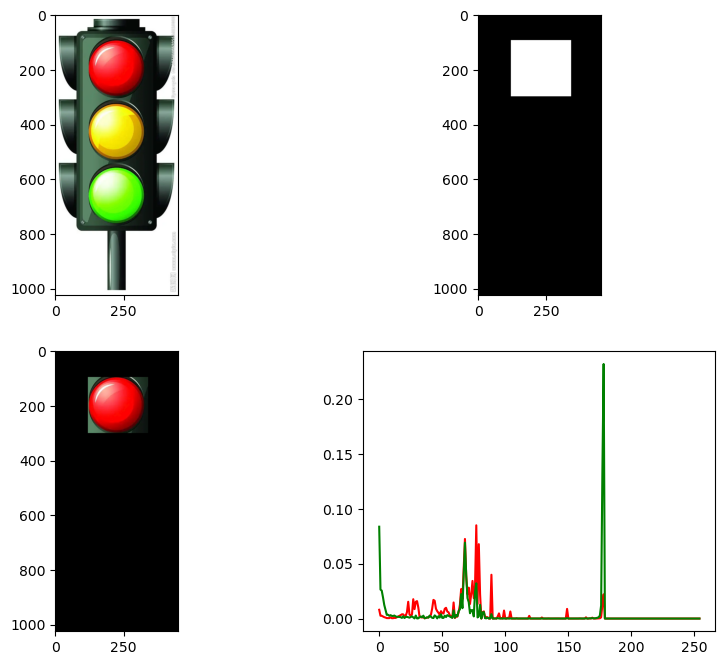

In [8]:
img = cv.imread('../images/t.png')
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)

mask = np.zeros(img.shape[:2], np.uint8)
mask[95:300, 120:340] = 255

masked_img = cv.bitwise_and(img, img, mask=mask)

hist1 = cv.calcHist([img], [0], None, [256], [0, 256])[1:, :]
hist1 = hist1 / np.sum(hist1)
hist2 = cv.calcHist([masked_img], [0], mask, [256], [0, 256])[1:, :]
hist2 = hist2 / np.sum(hist2)

fig, axex = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(cv.cvtColor(img, cv.COLOR_HSV2RGB))
axex[0, 1].imshow(mask, cmap='gray')
axex[1, 0].imshow(cv.cvtColor(masked_img, cv.COLOR_HSV2RGB))
axex[1, 1].plot(hist1, color='r')
axex[1, 1].plot(hist2, color='g')
plt.show()

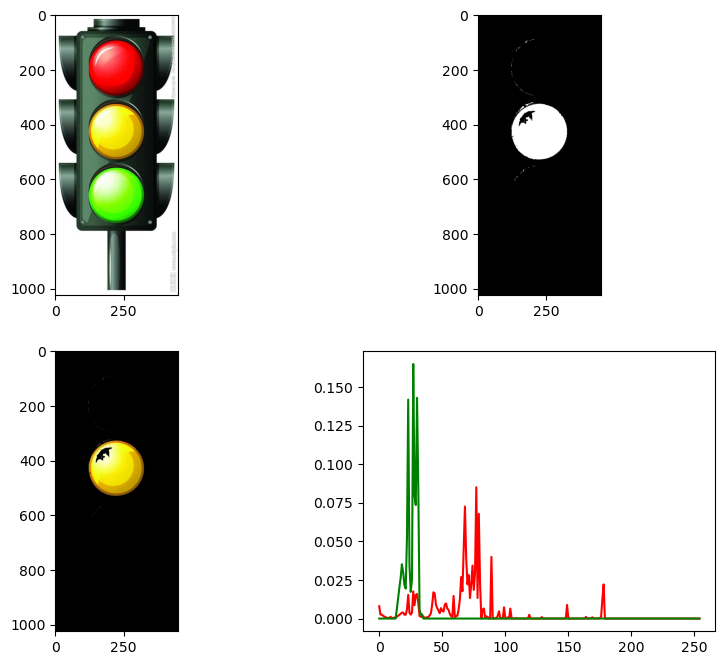

In [9]:
img = cv.imread('../images/t.png')
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)
lower = np.array([15, 50, 50])
upper = np.array([35, 255, 255])

mask = cv.inRange(img, lower, upper)
masked_img = cv.bitwise_and(img, img, mask=mask)

hist1 = cv.calcHist([img], [0], None, [256], [0, 256])[1:, :]
hist1 = hist1 / np.sum(hist1)
hist2 = cv.calcHist([masked_img], [0], mask, [256], [0, 256])[1:, :]
hist2 = hist2 / np.sum(hist2)

fig, axex = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(cv.cvtColor(img, cv.COLOR_HSV2RGB))
axex[0, 1].imshow(mask, cmap='gray')
axex[1, 0].imshow(cv.cvtColor(masked_img, cv.COLOR_HSV2RGB))
axex[1, 1].plot(hist1, color='r')
axex[1, 1].plot(hist2, color='g')
plt.show()

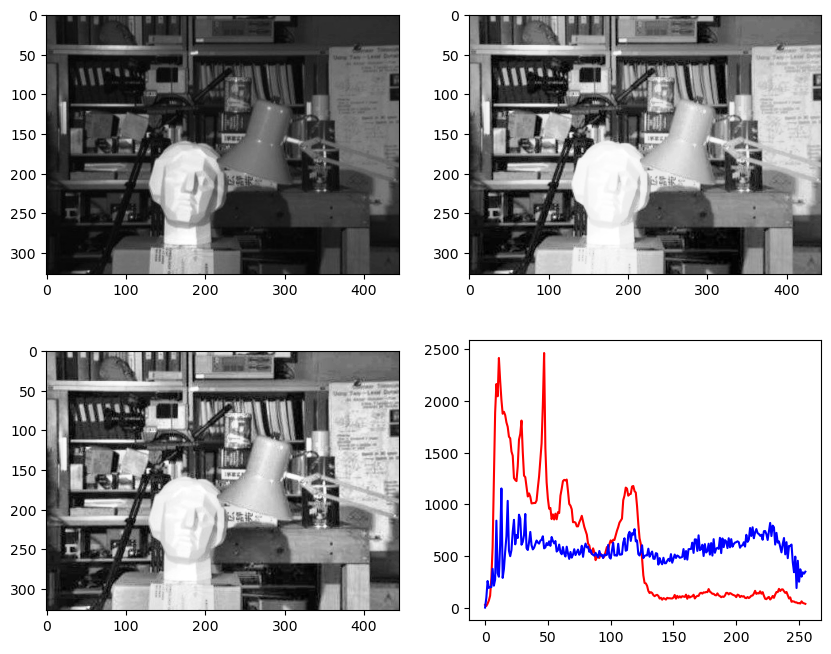

In [10]:
img = cv.imread('../images/tsukuba.png', 0)
img2 = cv.equalizeHist(img)
clathe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img3 = clathe.apply(img2)
hist1 = cv.calcHist([img], [0], None, [256], [0, 256])
# hist2 = cv.calcHist([img2], [0], None, [256], [0, 256])
hist3 = cv.calcHist([img3], [0], None, [256], [0, 256])

fig, axex = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(img, cmap='gray')
axex[0, 1].imshow(img2, cmap='gray')
axex[1, 0].imshow(img3, cmap='gray')
axex[1, 1].plot(hist1, color='r')
# axex[1, 1].plot(hist2, color='g')
axex[1, 1].plot(hist3, color='b')
plt.show()

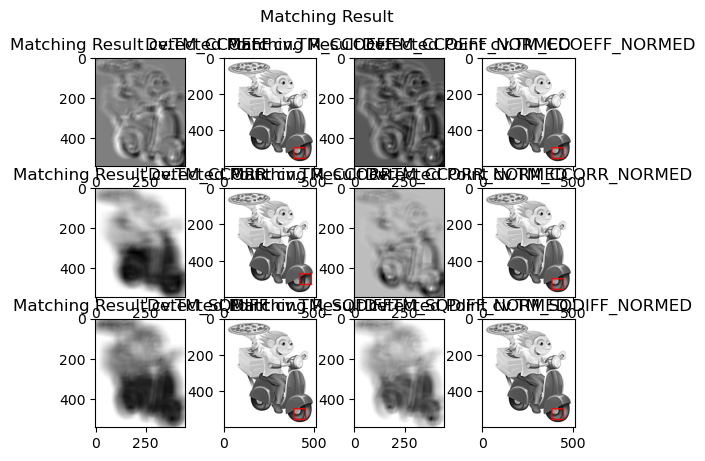

In [11]:
img = cv.imread('../images/xiaoren.png', cv.IMREAD_GRAYSCALE)
img2 = np.copy(img)

template = cv.imread('../images/template.png', cv.IMREAD_GRAYSCALE)
h, w = template.shape
methods = [
    'cv.TM_CCOEFF',  # 相关系数匹配法
    'cv.TM_CCOEFF_NORMED',  # 归一化相关系数匹配法
    'cv.TM_CCORR',  # 相关匹配法
    'cv.TM_CCORR_NORMED',  # 归一化相关匹配法
    'cv.TM_SQDIFF',  # 平方差匹配法
    'cv.TM_SQDIFF_NORMED'  # 归一化平方差匹配法
]
for idx, meth in enumerate(methods):
    img = np.copy(img2)

    method = eval(meth)

    res = cv.matchTemplate(img, template, method)

    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
    if method in [cv.TM_CCORR, cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)
    bgr_img = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
    cv.rectangle(bgr_img, top_left, bottom_right, color=[0, 0, 255], thickness=5)
    plt.subplot(len(methods) // 2, 4, 2 * idx + 1)
    plt.imshow(res, cmap='gray')
    plt.title(f'Matching Result {meth}')
    plt.subplot(len(methods) // 2, 4, 2 * idx + 2)  # 右图
    plt.imshow(cv.cvtColor(bgr_img, cv.COLOR_BGR2RGB))  # 原图（带矩形）
    plt.title(f'Detected Point {meth}')

plt.suptitle("Matching Result")  # 总标题
plt.show()

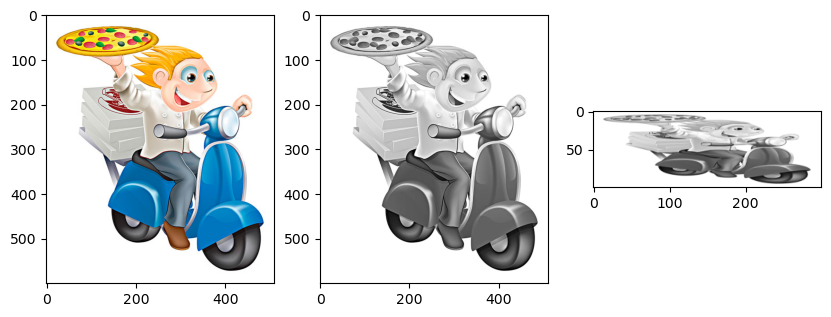

In [12]:
img = ski_io.imread("../images/xiaoren.png")
img2 = ski_color.rgb2gray(img)

img3 = ski_transform.resize(img2, (100, 300))

fig, axex = plt.subplots(1, 3, figsize=(10, 8), dpi=100)
axex[0].imshow(img, cmap='gray')
axex[1].imshow(img2, cmap='gray')
axex[2].imshow(img3, cmap='gray')
plt.show()

In [13]:
hog_feature = ski_feature.hog(img3)
print(hog_feature.shape)

(28350,)


In [14]:
img3 = np.uint8(img3)

lbp_feature = ski_feature.local_binary_pattern(img3, P=8, R=0.5).reshape(-1)
print(lbp_feature.shape)

(30000,)


In [15]:
corner_harris_feature = ski_feature.corner_harris(img3).reshape(-1)
print(corner_harris_feature.shape)

(30000,)


In [16]:
face_cascade = cv.CascadeClassifier('../models/haarcascade_frontalface_default.xml')
eye_cascade = cv.CascadeClassifier('../models/haarcascade_eye.xml')

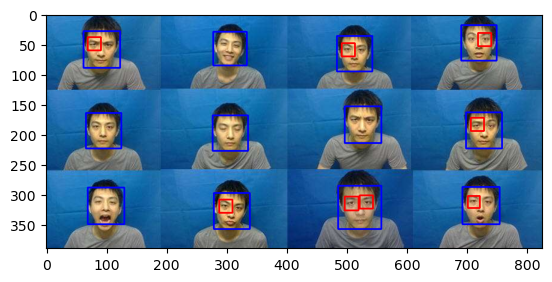

In [17]:
# 加载图像
img = cv.imread('../images/faces.png')
# 转为灰度图
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 检测人脸
# scaleFactor=1.3：用于检测不同大小的人脸。值越大，检测速度越快，但可能漏检小脸；值越小（>1），检测更彻底但速度更慢
# minNeighbors=5：控制误检的参数。值越大，检测到的人脸数量越少，但质量越高（减少误检）；值越小，可能返回更多人脸但包含更多误检
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

for x, y, w, h in faces:
    cv.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

    roi_gray = gray[y:y + h, x:x + w]  # 灰度图
    roi_img = img[y:y + h, x:x + w]  # 原图
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv.rectangle(roi_img, (ex, ey), (ex + ew, ey + eh), (0, 0, 255), 2)

plt.imshow(img[:, :, ::-1])
plt.show()

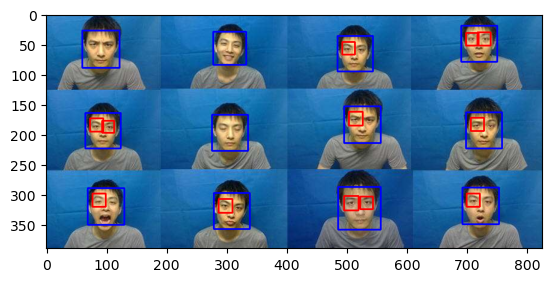

In [18]:
def face_detect_return_points(img):
    face_points = []
    eye_points = []
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    for (x, y, w, h) in faces:
        face_points.append([x, y, x + w, y + h])
        roi_gray = gray[y:y + h, x:x + w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            eye_points.append([ex + x, ey + y, ex + ew + x, ey + eh + y])
    return face_points, eye_points


def draw_rect(img, face_points, eye_points):
    for x1, y1, x2, y2 in face_points:
        cv.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    for x1, y1, x2, y2 in eye_points:
        cv.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
    return img


def face_detect(img, flag=True):
    global global_face_points, global_eye_points
    if flag:
        face_points, eye_points = face_detect_return_points(img)
        global_face_points = face_points
        global_eye_points = eye_points
    return draw_rect(img, global_face_points, global_eye_points)


img = cv.imread('../images/faces.png')
plt.imshow(face_detect(img)[:, :, ::-1])
plt.show()

In [19]:
capture = cv.VideoCapture(0)
success, frame = capture.read()
while success and cv.waitKey(1) == -1:
    img = frame
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    for (x, y, w, h) in faces:
        cv.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
        roi_gray = gray[y:y + h, x:x + w]
        roi_img = img[y:y + h, x:x + w]

        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            cv.rectangle(roi_img, (ex, ey), (ex + ew, ey + eh), (0, 0, 255), 2)
    cv.imshow('frame', img)

    # 读取下一帧的图像
    success, frame = capture.read()

# 释放资源
capture.release()
cv.destroyAllWindows()

In [20]:
capture = cv.VideoCapture(0)
success, frame = capture.read()
while success and cv.waitKey(1) == -1:
    img = frame
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    if len(faces) > 0:
        pass
    cv.imshow('frame', img)
    success, frame = capture.read()
# 释放资源
capture.release()
cv.destroyAllWindows()

In [21]:
def preprocess(gray):
    gaussian = cv.GaussianBlur(gray, ksize=(3, 3), sigmaX=0, sigmaY=0, borderType=cv.BORDER_DEFAULT)
    median = cv.medianBlur(gaussian, ksize=5)
    sobel = cv.Sobel(median, ddepth=cv.CV_64F, dx=1, dy=0, ksize=3)
    sobel = np.uint8(np.absolute(sobel))

    ret, binary = cv.threshold(sobel, 170, 255, cv.THRESH_BINARY)

    element1 = cv.getStructuringElement(shape=cv.MORPH_RECT, ksize=(9, 1))
    element2 = cv.getStructuringElement(shape=cv.MORPH_RECT, ksize=(9, 7))
    dilation = cv.dilate(binary, kernel=element2, iterations=1)
    erosion = cv.erode(dilation, kernel=element1, iterations=2)
    dilation2 = cv.dilate(erosion, kernel=element2, iterations=5)
    erosion2 = cv.erode(dilation2, kernel=element1, iterations=4)

    fig, axex = plt.subplots(3, 3, figsize=(10, 8), dpi=100)
    axex[0, 0].imshow(gray, cmap='gray')
    axex[0, 1].imshow(gaussian, cmap='gray')
    axex[0, 2].imshow(median, cmap='gray')
    axex[1, 0].imshow(sobel, cmap='gray')
    axex[1, 1].imshow(binary, cmap='gray')
    axex[1, 2].imshow(dilation, cmap='gray')
    axex[2, 0].imshow(erosion, cmap='gray')
    axex[2, 1].imshow(dilation2, cmap='gray')
    axex[2, 2].imshow(erosion2, cmap='gray')

    return erosion2

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255]], dtype=uint8)

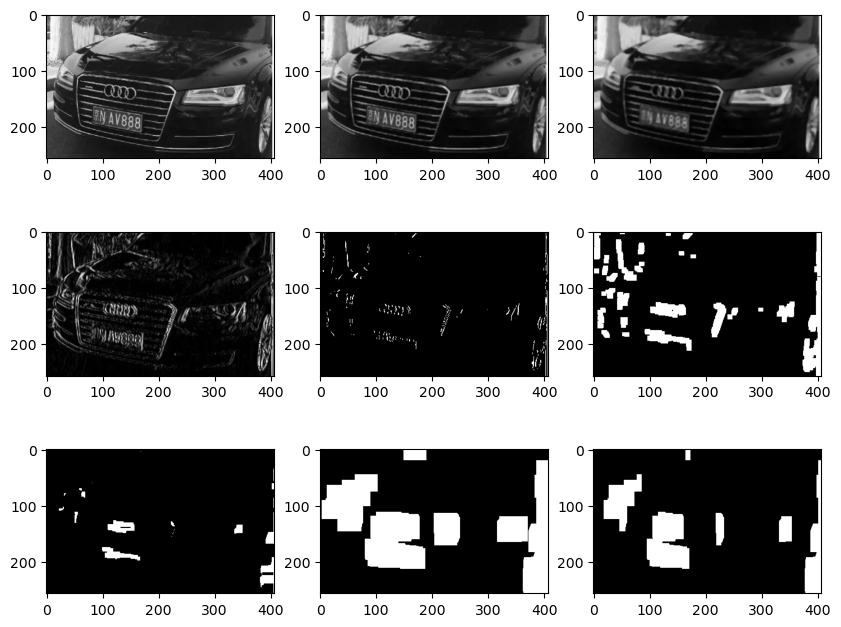

In [22]:
img = cv.imread("../images/car5.jpg", 0)
preprocess(img)

In [23]:
def find_plate_number_region(img):
    contours, hierarchy = cv.findContours(img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_SIMPLE)
    max_ratio = -1  # 记录最大的宽高比
    max_box = None  # 记录最大宽高比的外接矩形
    ratios = []  # 存储所有符合条件的宽高比和对应的轮廓
    number = 0  # 记录符合条件的轮廓数量
    for i in range(len(contours)):
        cnt = contours[i]
        area = cv.contourArea(cnt)
        if area < 10000:
            continue
        rect = cv.minAreaRect(cnt)
        box = cv.boxPoints(rect)
        box = np.int64(box)
        a = abs(box[0][0] - box[1][0])
        b = abs(box[0][1] - box[1][1])
        h = np.sqrt(a ** 2 + b ** 2)
        c = abs(box[1][0] - box[2][0])
        d = abs(box[1][1] - box[2][1])
        w = np.sqrt(c ** 2 + d ** 2)
        height = int(min(h, w))
        width = int(max(h, w))

        area2 = height * width

        r = np.absolute((area2 - area) / area)
        if r > 0.6:
            continue

        ratio = float(width) / float(height)

        cv.drawContours(img, [box], contourIdx=0, color=255, thickness=2)
        cv.imshow('img', img)
        cv.waitKey(0)
        cv.destroyAllWindows()
        if ratio > max_ratio:
            max_box = box
            max_ratio = ratio

        if ratio > 5.5 or ratio < 2:
            continue

        number += 1
        ratios.append((box, ratio))

    if number == 1:
        return ratios[0][0]
    elif number > 1:
        filter_ratios = list(filter(lambda t: t[1] >= 2.7 and t[1] <= 5.0, ratios))
        size_filter_ratios = len(filter_ratios)

        if size_filter_ratios == 1:
            return filter_ratios[0][0]
        elif size_filter_ratios > 1:
            ratios1 = [filter_ratios[i][1] for i in range(size_filter_ratios)]
            ratios1 = list(zip(range(size_filter_ratios), ratios1))
            ratios1 = sorted(ratios1, key=lambda t: t[1])
            idx = ratios1[size_filter_ratios // 2][0]
            return filter_ratios[idx][0]
        else:
            ratios1 = [ratios[i][1] for i in range(number)]
            ratios1 = list(zip(range(number), ratios1))
            ratios1 = sorted(ratios1, key=lambda t: t[1])
            idx = ratios1[-1][0]
            return filter_ratios[idx][0]
    else:
        print("直接返回最接近比例的区域...")
        return max_box

In [24]:
def cut(img_or_img_path):
    if isinstance(img_or_img_path, str):
        img = cv.imread(img_or_img_path)
    else:
        img = img_or_img_path

    rows, cols, _ = img.shape

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    dilation = preprocess(gray)

    box = find_plate_number_region(dilation)

    ys = [box[0, 1], box[1, 1], box[2, 1], box[3, 1]]  # 4个顶点的 y 坐标
    xs = [box[0, 0], box[1, 0], box[2, 0], box[3, 0]]  # 4个顶点的 x 坐标
    ys_sorted_index = np.argsort(ys)  # 对 y 坐标排序，返回索引
    xs_sorted_index = np.argsort(xs)  # 对 x 坐标排序，返回索引
    x1 = box[xs_sorted_index[0], 0]  # 最小的 x 坐标（左边界）
    x1 = x1 if x1 > 0 else 0  # 确保不小于 0
    x2 = box[xs_sorted_index[3], 0]  # 最大的 x 坐标（右边界）
    x2 = cols if x2 > cols else x2  # 确保不超过图像宽度

    y1 = box[ys_sorted_index[0], 1]  # 最小的 y 坐标（上边界）
    y1 = y1 if y1 > 0 else 0  # 确保不小于 0
    y2 = box[ys_sorted_index[3], 1]  # 最大的 y 坐标（下边界）
    y2 = rows if y2 > rows else y2  # 确保不超过图像高度
    img_plate = img[y1:y2, x1:x2]

    return img_plate

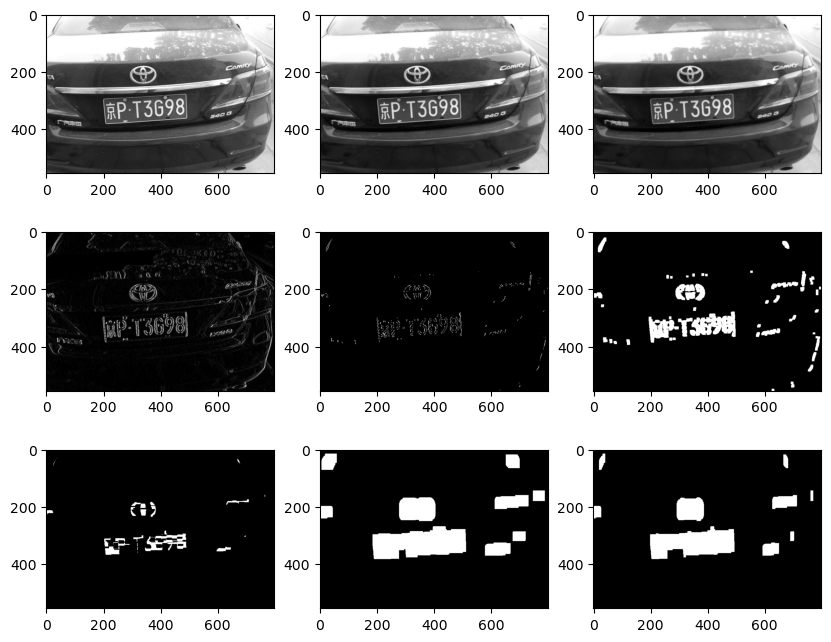

In [25]:
path = '../images/car2.jpg'
cut_img = cut(path)
filename = path.split("/")[-1]

cv.imshow('image', cv.imread(path))  # 原图
cv.imshow('plat', cut_img)  # 车牌
cv.waitKey(0)
cv.destroyAllWindows()

In [26]:
img = cv.imread("../images/car3.jpg")

pts1 = np.float32([[-13, 464], [34, 337], [271, 425], [223, 553]])  # 原图像：照片上的车牌
pts2 = np.float32([[0, 100], [0, 0], [300, 0], [300, 100]])  # 新图像：标准车牌

M = cv.getPerspectiveTransform(pts1, pts2)
print("透视转换矩阵M：\n", M)
rot_image = cv.warpPerspective(img, M, (300, 100))

cv.imshow('image', img)  # 原图
cv.imshow('rot_image', rot_image)  # 透视转换
cv.waitKey(0)
cv.destroyAllWindows()

透视转换矩阵M：
 [[ 1.12394045e+00  4.15946467e-01 -1.78387935e+02]
 [-2.56555633e-01  6.90950967e-01 -2.24127584e+02]
 [ 4.12658545e-05 -2.96264794e-06  1.00000000e+00]]


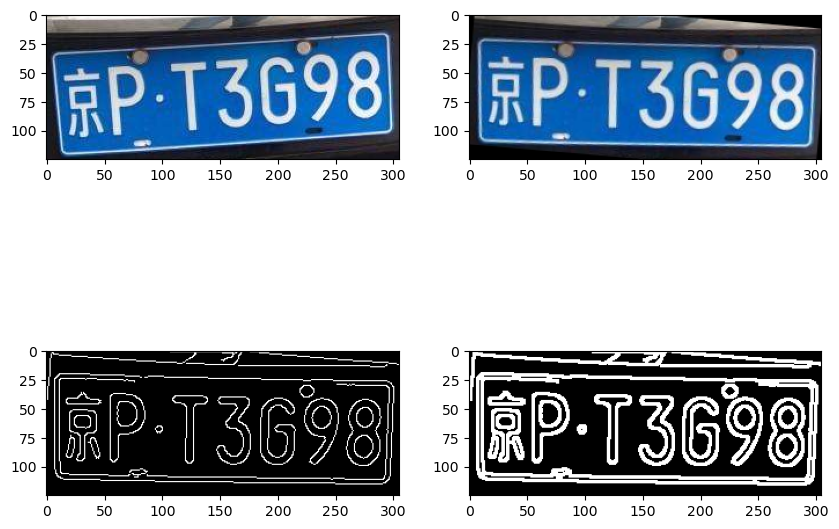

In [27]:
rows, cols, _ = cut_img.shape
M = cv.getRotationMatrix2D(center=(cols / 2, rows / 2), angle=-4.808, scale=1)
cut_img2 = cv.warpAffine(cut_img, M, dsize=(cols, rows), borderValue=[0, 0, 0])
gray = cv.cvtColor(cut_img2, cv.COLOR_BGR2GRAY)
gaussian = cv.GaussianBlur(gray, ksize=(3, 3), sigmaX=0, sigmaY=0, borderType=cv.BORDER_DEFAULT)
median = cv.medianBlur(gaussian, ksize=5)
edges = cv.Canny(median, threshold1=50, threshold2=250)

ret, binary = cv.threshold(edges, 170, 255, cv.THRESH_BINARY)
element2 = cv.getStructuringElement(shape=cv.MORPH_RECT, ksize=(3, 3))
dilation = cv.dilate(binary, kernel=element2, iterations=1)

fig, axex = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(cut_img[:, :, ::-1])
axex[0, 1].imshow(cut_img2[:, :, ::-1])
axex[1, 0].imshow(binary, cmap='gray')
axex[1, 1].imshow(dilation, cmap='gray')
plt.show()

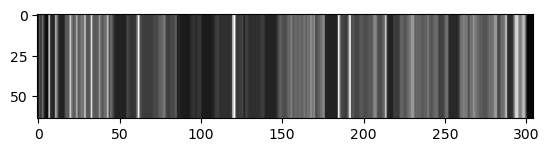

In [28]:
v = binary              
v = np.mean(v, axis=0)
v = v * 2.5
v = v.astype(np.uint8)
vv = np.array([
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v
])
plt.imshow(vv, cmap='gray')
plt.show()

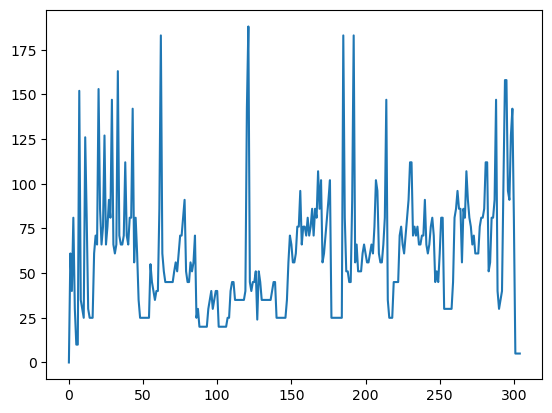

In [29]:
# 绘制一维数组 v 的曲线图，用于直观展示数据分布
import matplotlib.pyplot as plt

plt.plot(v)
plt.show()